# Methodology preparation

## Image Union Section
What pixel range of the 7DT image can we use?


- Are pixel-wcs informations of images same?

In [22]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.stats import sigma_clipped_stats
import matplotlib.pyplot as plt
import numpy as np
import glob
from pathlib import Path

# Image preparation
COSMOS = 3
DATA_ROOT = Path("../COSMOS_data")

def get_image_path(cosmos, band, weight=False):
    image_folder = DATA_ROOT / f"COSMOS{cosmos}"

    suffix = "weight.fits" if weight else "com.fits"
    paths = list(image_folder.glob(f"*{band}*.{suffix}"))

    if len(paths) == 0:
        print(
            f"COSMOS {cosmos} - {band}: no matching {suffix} file."
        )
        return None

    if len(paths) > 1:
        raise RuntimeError(
            f"COSMOS {cosmos} - {band}: multiple matching {suffix} files."
        )

    return paths[0]


# 1. Check a "same pixel - same WCS" assumtion
bands_7DT = sorted({f'm{i}' for i in range(400, 900, 25)})

# Check sample image
with fits.open(get_image_path(COSMOS, "m400")) as sample_hdul :
    sample_hdul.info() 
    sample_data = sample_hdul[0].data
    sample_header = sample_hdul[0].header

# sample image plot
# norm = ImageNormalize(sample_data, interval=ZScaleInterval() )
# plt.imshow(
#     sample_data,
#     origin='lower',
#     cmap='gray', 
#     norm=norm
# )

# check basic statistics of sample image
mean, median, std = sigma_clipped_stats(
    data=sample_data, 
    sigma=3.0
)
print(
    f"mean : {mean} \nmedian : {median}\nstd : {std}"
)


# check outer region pixel value
print("Outer region pixel value : ", sample_data[6750, 10000]) # 0.0
    

Filename: ../COSMOS_data/COSMOS3/calib_7DT_COSMOS_3_20240525_234833_m400_1920.com.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     223   (10200, 6800)   float32   
mean : 0.4547828435897827 
median : 0.23028501868247986
std : 1.5881941318511963
Outer region pixel value :  0.0


**Result : pixel-wcs is same for all bands**

In [23]:
# WCS value of test pixel in each bands
# test pixel : 5100, 3400(middle) - by hdul info 
test_list = []

for band in bands_7DT:
    band_path = get_image_path(COSMOS, band)
    if band_path == None : continue
    
    with fits.open(band_path) as hdul : 
        data = hdul[0].data
        header = hdul[0].header
    wcs = WCS(header)
    ra, dec = wcs.pixel_to_world_values(5100, 3400)
    test_list.append( np.array([ra, dec]) )

for i in test_list : 
    print(i)

COSMOS 3 - m650: no matching com.fits file.
COSMOS 3 - m675: no matching com.fits file.
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]
[150.39992982   1.95007014]


- Make mask in that all bands have a value.

In [24]:
# check sample weight
# Check sample image
with fits.open(get_image_path(COSMOS, "m400", weight=True)) as sample_hdul :
    sample_hdul.info() 
    sample_data = sample_hdul[0].data
    sample_header = sample_hdul[0].header

# sample image plot
# plt.imshow(sample_data, origin='lower')

# check outer region pixel value
print("Outer region pixel value : ", sample_data[6750, 10000]) 
print("Inner region pixel value : ", sample_data[3400, 5100])
# d = sample_data.ravel()
# plt.hist(d, bins=500)
# plt.show()


Filename: ../COSMOS_data/COSMOS3/calib_7DT_COSMOS_3_20240525_234833_m400_1920.weight.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     173   (10200, 6800)   float32   
Outer region pixel value :  0.0
Inner region pixel value :  0.29677585


We can determine edge using weight file. And we can make **boolean mask array**.

COSMOS 3 - m650: no matching weight.fits file.
COSMOS 3 - m675: no matching weight.fits file.


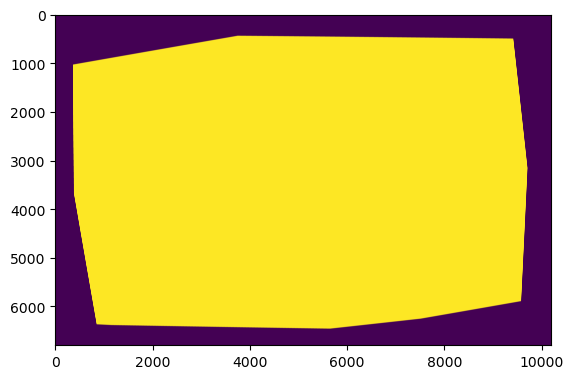

In [25]:
valid_mask = None

for band in bands_7DT:
    band_path = get_image_path(COSMOS, band, weight=True)
    if band_path == None : continue
    
    with fits.open(band_path) as hdul : 
        weight = hdul[0].data
        header = hdul[0].header
    valid = weight > 0.0
    
    if valid_mask is None : 
        valid_mask = valid
    else : 
        valid_mask &= valid


# make mask fits
plt.imshow(valid_mask)
valid_mask = valid_mask.astype(np.uint8)
with fits.open(get_image_path(COSMOS, "m400", weight=True)) as sample_hdul :
    sample_header = sample_hdul[0].header
    mask_header = sample_header.copy()
    
fits.writeto(
    DATA_ROOT/f"COSMOS{COSMOS}/COSMOS{COSMOS}_validmask.fits", 
    valid_mask, 
    header=mask_header, 
    overwrite=True
)
